In [1]:
import EOSutils as meos

import numpy as np
import matplotlib.pyplot as plt

import matplotlib.style
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.cm as cmx
from mpl_toolkits.axes_grid1 import make_axes_locatable


mpl.style.use('classic')

from astropy.table import Table
from astropy import units as u
from astropy.constants import G

import mesa_helper as mh
import os
import shutil
import copy

from scipy import interpolate,ndimage
from scipy.linalg import lstsq as scipy_lstsq
from scipy.ndimage import gaussian_filter
import scipy.integrate as integrate
import decimal 
import pickle

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# load SCVH tables, which have H2 vs. H, He vs. He+ fraction informaton for mu, mu_e calcs
infile = open("../SCVH_H_rhoT_with_Hfractions.pkl","rb")
scvh_H_rhoT = pickle.load(infile)
infile.close()

infile = open("../SCVH_He_rhoT_with_Hefractions.pkl","rb")
scvh_He_rhoT = pickle.load(infile)
infile.close()

In [3]:
def MESA_cols_6to16(table, X=1, Y=0, mu_Z=None, calc_eta=False):
    """
    this assumes that the following attributes are already defined:
    table.log10Tgrid
    table.log10rhogrid
    table.log10Pgrid
    table.log10Egrid
    table.log10Sgrid
    table.chiRho
    table.dlS_dlrho_T
    table.chiT
    table.dlS_dlT_rho

    and that the remainder of the MESA columns already exist in the table object, they just currently equal None.
    """
    S = 10**table.log10Sgrid #erg g^-1 K^-1
    rho = 10**table.log10rhogrid # g cm^-3
    E = 10**table.log10Egrid # erg g^-1
    T = 10**table.log10Tgrid # K

    dlrho_dlT_P = -1. * table.chiT/table.chiRho
    dlrho_dlP_T = 1./table.chiRho 

    dlS_dlT_P = table.dlS_dlT_rho - (table.dlS_dlrho_T * (table.chiT/table.chiRho))
    dlS_dlP_T = table.dlS_dlrho_T/table.chiRho

    # prevent negative chiRho, chiT, Cp, Cv, gamma1, grad_ad values by eliminating wrong-signed finite difference quantities ahead of time
    # chiRho, chiT must be positive
    # dlS_dlT_P, dlS_dlT_rho must be positive
    # dlS_dlP_T, dlS_dlrho_T must be negative

    # set wrong-signed values to nan
    table.chiRho[table.chiRho <= 0] = np.nan
    table.chiT[table.chiT <= 0] = np.nan
    dlS_dlT_P[dlS_dlT_P <= 0] = np.nan
    table.dlS_dlT_rho[table.dlS_dlT_rho <= 0] = np.nan
    dlS_dlP_T[dlS_dlP_T >= 0] = np.nan
    table.dlS_dlrho_T[table.dlS_dlrho_T >= 0] = np.nan

    # fill in by interpolation    
    table.chiRho = meos.fill_in_nans(table.chiRho, table)
    table.chiT = meos.fill_in_nans(table.chiT, table)
    dlS_dlT_P = meos.fill_in_nans(dlS_dlT_P, table)
    table.dlS_dlT_rho = meos.fill_in_nans(table.dlS_dlT_rho, table)
    dlS_dlP_T = meos.fill_in_nans(dlS_dlP_T, table)
    table.dlS_dlrho_T = meos.fill_in_nans(table.dlS_dlrho_T, table)

    table.grad_ad = -1.* table.dlS_dlrho_T/((table.chiRho*table.dlS_dlT_rho) - (table.chiT*table.dlS_dlrho_T))
    
    table.Cp = S * dlS_dlT_P
    table.Cv = S * table.dlS_dlT_rho

    table.dE_drho_T = table.dlE_dlrho_T * (E/rho) #dE/drho = (dlE/dlrho) * (E/rho)
    table.dS_dT_rho = table.dlS_dlT_rho * (S/T) #dS/dT = (dlS/dlT) * (S/T)
    table.dS_drho_T = table.dlS_dlrho_T * (S/rho) #dS/drho = (dlS/dlrho) * (S/rho)

   # below assumes fully ionized material! wrong (see Helled+2025, SCVH paper)
    #table.mu = (4./(6*X + 4*Y + 2))*np.ones_like(table.log10Tgrid)
    #table.log_free_e = np.log10(0.5*(1+X))*np.ones_like(table.log10Tgrid) # = 1/mu_e 

    # correct proportions of molecular/atomic/ionized material extrapolated from SCVH
    f_H2 = scvh_H_rhoT.nm_grid
    f_H = scvh_H_rhoT.na_grid

    f_He = scvh_He_rhoT.nm_grid
    f_Heplus = scvh_He_rhoT.na_grid

    mu_H = 0.5 + 1.5*f_H2 + 0.5*f_H
    mu_He = (4./3.) + (8./3.)*f_He + (4./3.)*f_Heplus
        
    Z = 1. - X - Y

    if Z > 0:  
        mu_tot = 1./((X/mu_H) + (Y/mu_He) + (Z/mu_Z))
    else:
        mu_tot = 1./((X/mu_H) + (Y/mu_He))
        
    table.mu = mu_tot

    #for pure metal tables, mu_e = 0 and log_free_e = -inf
    if Z == 1.:
        table.log_free_e = -100.*np.ones_like(table.log10Tgrid)
    else:
        mu_e = 1./( X*((1.-f_H2-f_H)/(2*mu_H)) + Y*((2.-2*f_He-f_Heplus)/(3.*mu_He)) )
        table.log_free_e = np.log10(1./mu_e)

    table.gamma3 = (-1. * (table.dlS_dlrho_T/table.dlS_dlT_rho)) + 1.
    table.gamma1 = table.chiT*(table.gamma3 - 1.) + table.chiRho

    table.gamma1[table.gamma1 <= 0] = np.nan
    table.grad_ad[table.grad_ad <= 0] = np.nan
    table.gamma1 = meos.fill_in_nans(table.gamma1, table)
    table.grad_ad = meos.fill_in_nans(table.grad_ad, table)
    
    table.eta = np.zeros_like(table.log10Tgrid)

    if calc_eta is True:
        for i in range(np.shape(table.log10Tgrid)[1]):
            print(table.log10Tgrid[1][i])
            for j in range(np.shape(table.log10rhogrid)[0]):
                this_recip_mu_e = (10**table.log_free_e[j,i])
                this_n_e = 10**table.log10rhogrid[j,i] * this_recip_mu_e * (1/m_p) # g/cm^3 * e-/amu * amu/g = e-/cm^3
                this_T = 10**table.log10Tgrid[j,i]
                rhs = (this_n_e * h**3)/(4*np.pi*(2*m_e*kB*this_T)**(3./2.))
                theta = (kB*this_T)/(m_e*c**2)
    
                # if too few free e-, then just set eta to an arbitrary low value (same thing is done in MESA EoS code)
                if table.log_free_e[j,i]  <= -4:
                    opt_eta_ = -20
                else:
                    #print("")
                    #print(this_n_e)
                    #print(this_T)
                    #print(theta)
                    #print(rhs)
                    opt_eta_ = solve_fdint(rhs=rhs,theta=theta)
                table.eta[j,i] = opt_eta_
        

    return

In [4]:
class log10Q_log10T_table(object):
    def __init__(self, units='cgs', **kwargs):
        if units == 'cms' or units == 'cgs' or units == 'CMS':
            self.units = units
        else: 
            print('units must be cgs or mks or CMS (T [K], P [GPa], rho [g/cm^3], U [MJ/kg], S [MJ/kg/K])')

        self.X = None
        self.Y = None
        
        self.atomic_number = None
        self.mass_number = None

        self.log10Qgrid_QT = None
        self.log10Tgrid_QT = None
        self.log10Pgrid_QT = None
        self.log10Egrid_QT = None
        self.log10Sgrid_QT = None

        self.chiRho_QT = None 
        self.chiT_QT = None 
        self.Cp_QT = None
        self.Cv_QT = None

        self.dE_drho_T_QT = None
        self.dS_dT_rho_QT = None
        self.dS_drho_T_QT = None
        self.mu_QT = None
        self.log_free_e_QT = None
        self.gamma1_QT = None
        self.gamma3_QT = None
        self.grad_ad_QT = None
        self.eta_QT = None
        

In [5]:
def extrapolate_to_wide_rho_grid(old_attrgrid, old_rhoarr, old_Tarr, new_rhogrid, new_Tgrid):
    """
    takes a grid defined on -8 <= log10rho <= 6 and linearly extrapolates it to -20 <= log10rho <= 9.4, which is wide enough to include the entire rectangular log10Q grid
    """

    interp_attr_given_log10rho_log10T = interpolate.RegularGridInterpolator(points=(old_rhoarr, old_Tarr), values=old_attrgrid, bounds_error=False, fill_value=None, method='linear')

    new_attrgrid = interp_attr_given_log10rho_log10T((new_rhogrid, new_Tgrid))

    return new_attrgrid

In [6]:
def cut_out_relevant_Q(new_attrgrid, new_rhogrid, new_Tgrid):

    Qgrid = new_rhogrid - 2*new_Tgrid + 12

    desired_Qarr = np.arange(-12.,5.45,0.05)
    desired_Tarr = new_Tgrid[0]
    existing_rhoarr = new_rhogrid[:,0]

    masked_attrgrid = np.zeros_like(new_attrgrid)
    masked_rhogrid = np.zeros_like(new_attrgrid)
    masked_Tgrid = np.zeros_like(new_attrgrid)

    for i,rho in enumerate(existing_rhoarr):
        for j,T in enumerate(desired_Tarr):
            q = rho - 2*T + 12
            if (q >= -12) and (q <= 5.4):
                masked_attrgrid[i, j] = new_attrgrid[i,j]
                masked_rhogrid[i, j] = new_rhogrid[i,j]
                masked_Tgrid[i, j] = new_Tgrid[i,j]
            else:
                masked_attrgrid[i, j] = np.nan
                masked_rhogrid[i, j] = np.nan
                masked_Tgrid[i, j] = np.nan
            
    return masked_attrgrid, masked_rhogrid, masked_Tgrid

In [7]:
def change_to_QT(widerho_attr_grid, widerho_grid, widerho_Tgrid):

    desired_Qarr = np.arange(-12.,5.45,0.05)
    desired_Tarr = widerho_Tgrid[0]

    current_Qgrid = widerho_grid - 2*widerho_Tgrid + 12
    #print(current_Qgrid)

    Qgrid, Tgrid = np.meshgrid(desired_Qarr, desired_Tarr)
    #print(Qgrid[:,0])

    attr_QTgrid = np.zeros_like(Qgrid)
    #print(Qgrid)
    
    for i, q in enumerate(desired_Qarr):

        thisQmask = (np.abs(current_Qgrid - q) < 0.01)
        #print(len(widerho_Tgrid[thisQmask]))
        attr_QTgrid[:,i] = widerho_attr_grid[thisQmask]
        
    
    return attr_QTgrid

In [8]:
def change_table_coordinates(table, extrapolation_row_idxs=None,extrapolation_col_idxs=None):
    """
    input table must already have all MESA columns defined
    """

    QT_table = log10Q_log10T_table()

    QT_table.X = table.X
    QT_table.Y = table.Y
    if hasattr(table, 'atomic_number'):
        QT_table.atomic_number = table.atomic_number
    if hasattr(table, 'mass_number'):
        QT_table.mass_number = table.mass_number

    Tarr = table.log10Tgrid[0]
    Qarr = np.unique(np.round(table.log10Qgrid[table.log10Qgrid <= 5.4],6))
    numlogQs = len(Qarr)
    logQmin = np.min(Qarr)
    logQmax = np.max(Qarr)
    dellogQ = Qarr[1] - Qarr[0]

    wide_Tgrid, wide_rhogrid = np.meshgrid(table.log10Tgrid[0], np.arange(-20.,9.45,0.05))

    wide_Pgrid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.log10Pgrid, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)

    desired_Qarr = np.arange(-12.,5.45,0.05)
    desired_Tarr = wide_Tgrid[0]

    QT_table.log10Qgrid_QT, QT_table.log10Tgrid_QT = np.meshgrid(desired_Qarr, desired_Tarr)

    QT_table.log10Pgrid_QT = change_to_QT(wide_Pgrid, wide_rhogrid, wide_Tgrid)
    #print(QT_table.log10Pgrid_QT[np.isnan(QT_table.log10Pgrid_QT)])

    wide_Egrid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.log10Egrid, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.log10Egrid_QT = change_to_QT(wide_Egrid, wide_rhogrid, wide_Tgrid)

    wide_Sgrid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.log10Sgrid, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.log10Sgrid_QT = change_to_QT(wide_Sgrid, wide_rhogrid, wide_Tgrid)

    # chiT, chiRho, Cp returning nans in the first 3 rows (T = 2.0,2.05,2.1). Fix this by extrapolation
    wide_chiRho_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.chiRho, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.chiRho_QT = change_to_QT(wide_chiRho_grid, wide_rhogrid, wide_Tgrid)
    QT_table.chiRho_QT = meos.fill_in_nans_QT(QT_table.chiRho_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_chiT_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.chiT, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.chiT_QT = change_to_QT(wide_chiT_grid, wide_rhogrid, wide_Tgrid)
    QT_table.chiT_QT = meos.fill_in_nans_QT(QT_table.chiT_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_Cp_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.Cp, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.Cp_QT = change_to_QT(wide_Cp_grid, wide_rhogrid, wide_Tgrid)
    QT_table.Cp_QT = meos.fill_in_nans_QT(QT_table.Cp_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_Cv_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.Cv, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.Cv_QT = change_to_QT(wide_Cv_grid, wide_rhogrid, wide_Tgrid)
    QT_table.Cv_QT = meos.fill_in_nans_QT(QT_table.Cv_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_dE_drho_T_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.dE_drho_T, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.dE_drho_T_QT = change_to_QT(wide_dE_drho_T_grid, wide_rhogrid, wide_Tgrid)
    QT_table.dE_drho_T_QT = meos.fill_in_nans_QT(QT_table.dE_drho_T_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_dS_dT_rho_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.dS_dT_rho, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)

    QT_table.dS_dT_rho_QT = change_to_QT(wide_dS_dT_rho_grid, wide_rhogrid, wide_Tgrid)
    QT_table.dS_dT_rho_QT = meos.fill_in_nans_QT(QT_table.dS_dT_rho_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_dS_drho_T_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.dS_drho_T, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.dS_drho_T_QT = change_to_QT(wide_dS_drho_T_grid, wide_rhogrid, wide_Tgrid)
    QT_table.dS_drho_T_QT = meos.fill_in_nans_QT(QT_table.dS_drho_T_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_mu_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.mu, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.mu_QT = change_to_QT(wide_mu_grid, wide_rhogrid, wide_Tgrid)

    wide_log_free_e_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.log_free_e, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.log_free_e_QT = change_to_QT(wide_log_free_e_grid, wide_rhogrid, wide_Tgrid)

    table.gamma1[table.gamma1 <= 0] = np.nan
    table.grad_ad[table.grad_ad <= 0] = np.nan
    
    wide_gamma1_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.gamma1, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.gamma1_QT = change_to_QT(wide_gamma1_grid, wide_rhogrid, wide_Tgrid)
    QT_table.gamma1_QT = meos.fill_in_nans_QT(QT_table.gamma1_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_gamma3_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.gamma3, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.gamma3_QT = change_to_QT(wide_gamma3_grid, wide_rhogrid, wide_Tgrid)
    QT_table.gamma3_QT = meos.fill_in_nans_QT(QT_table.gamma3_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_grad_ad_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.grad_ad, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.grad_ad_QT = change_to_QT(wide_grad_ad_grid, wide_rhogrid, wide_Tgrid)
    QT_table.grad_ad_QT = meos.fill_in_nans_QT(QT_table.grad_ad_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)

    wide_eta_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.eta, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.eta_QT = change_to_QT(wide_eta_grid, wide_rhogrid, wide_Tgrid)

    # deal with the (vanishingly small) number of table entries where grad_ad or gamma1 rounds to 0
    QT_table.gamma1_QT[QT_table.gamma1_QT <= 1.e-5] += 1.e-5
    QT_table.grad_ad_QT[QT_table.grad_ad_QT <= 1.e-5] += 1.e-5
    
    return QT_table

In [9]:
#profiles = meos.load_sample_planet_profiles(Minit=np.array((1.09,7.59,20.0)), Rinit=2.0, Zinit=0.025, comps=['uniform','inert_core'], Sinit=np.array((9.0,11.0)), alphas=2.0, ages=np.array((1.e6,1.e10)))
profiles = meos.load_sample_planet_profiles(Minit=np.array((1.09,2.88,7.59,20.0)), Rinit=2.0, Zinit=0.025, comps=['uniform'], Sinit=np.array((9.0)), alphas=2.0, ages=np.array((1.e7,1.e10)))


In [10]:
smoothing_arr = np.array((1,2,5))
scaling_fac_arr = np.array((0.05,0.1,0.25))

# for plotting
x = np.arange(-12,5.45,0.05)
y1 = 2 - 0.5*x
y2 = 9 - 0.5*x



unphys_x = np.linspace(-8,6,50)
unphys_y = 3.3 + (1./2.)*np.linspace(-8,6,50) + np.log10(1) - (5./3)*np.log10(1)


In [11]:
infile = open("../cms19_mazevet2022_H_blend.pkl","rb")
bln_H = pickle.load(infile)
infile.close()

#start = time.time()
MESA_cols_6to16(bln_H,X=1.,Y=0.,calc_eta=False)
#end = time.time()
#print((end-start)/60.)

bln_H.log10Qgrid = bln_H.log10rhogrid - 2.*bln_H.log10Tgrid + 12
bln_H_QT = change_table_coordinates(bln_H)

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_30003/3994285155.py:16: RuntimeWarning: overflow encountered in power
  S = 10**table.log10Sgrid #erg g^-1 K^-1
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_30003/3994285155.py:18: RuntimeWarning: overflow encountered in power
  E = 10**table.log10Egrid # erg g^-1
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_30003/3994285155.py:53: RuntimeWarning: invalid value encountered in multiply
  table.dE_drho_T = table.dlE_dlrho_T * (E/rho) #dE/drho = (dlE/dlrho) * (E/rho)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_30003/3994285155.py:84: RuntimeWarning: divide by zero encountered in divide
  mu_e = 1./( X*((1.-f_H2-f_H)/(2*mu_H)) + Y*((2.-2*f_He-f_Heplus)/(3.*mu_He)) )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_30003/3994285155.py:85: RuntimeWarning: divide by zero encountered in log10
  table.log_free_e = np.log10(1./mu_e)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipyk

/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:328: RuntimeWarning: overflow encountered in power
  Fgrid = 10**table.log10Egrid - ((10**table.log10Tgrid) * (10**table.log10Sgrid))
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:328: RuntimeWarning: invalid value encountered in subtract
  Fgrid = 10**table.log10Egrid - ((10**table.log10Tgrid) * (10**table.log10Sgrid))
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:440: RuntimeWarning: invalid value encountered in log10
  self.F_log10Pgrid = np.log10(self.F_Pgrid)
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:441: RuntimeWarning: invalid value encountered in log10
  self.F_log10Sgrid = np.log10(self.F_Sgrid)
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:442: RuntimeWarning: invalid value encountered in log10
  self.F_log10Egrid = np.log10(self.F_Egrid)
/Users/emil

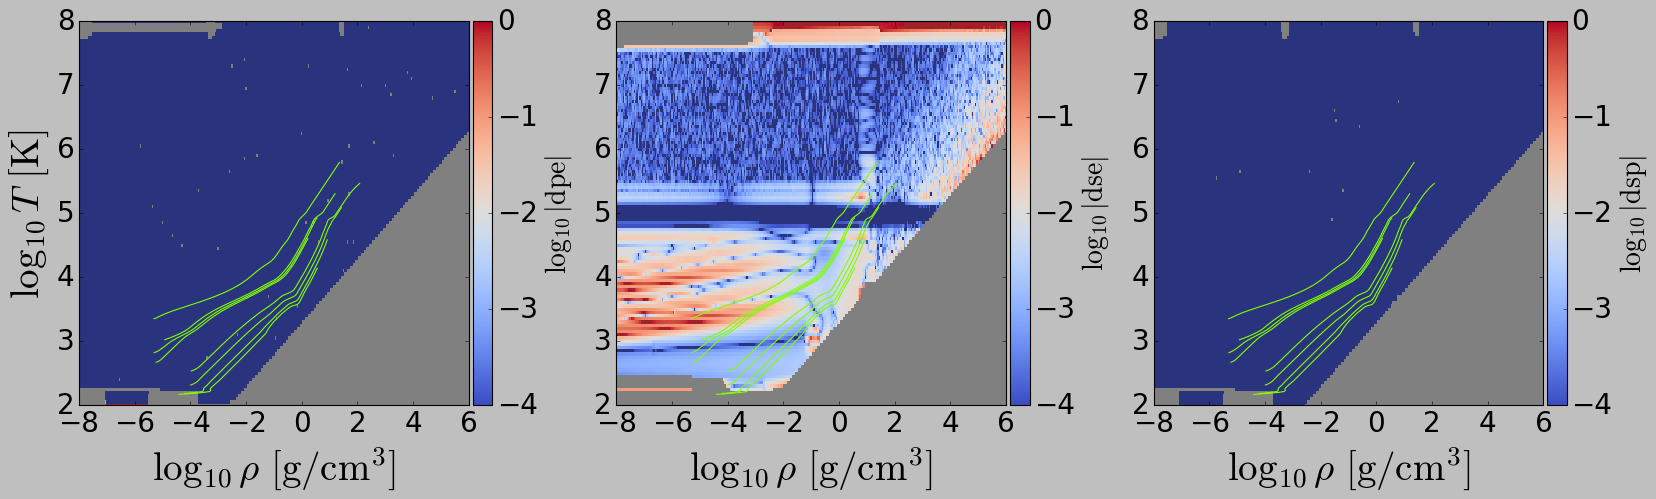

In [12]:
# no F smoothing
infile = open("../cms19_mazevet2022_H_blend.pkl","rb")
bln_H_TC = pickle.load(infile)
infile.close()

bln_H_TC.compute_F_table(F_smoothing_kernel=None, F_nan_fill_value='none')

# replace existing PSE grids with F-based versions
bln_H_TC.log10Pgrid = bln_H_TC.F_log10Pgrid
bln_H_TC.log10Sgrid = bln_H_TC.F_log10Sgrid
bln_H_TC.log10Egrid = bln_H_TC.F_log10Egrid

bln_H_TC.log10Ugrid = bln_H_TC.log10Egrid

bln_H_TC.compute_partials(species='H')

dpe, dse, dsp, a, b, c = meos.consistency_metrics(bln_H_TC, P=10**bln_H_TC.log10Pgrid,S=10**bln_H_TC.log10Sgrid,E=10**bln_H_TC.log10Egrid,species='H',order=8,maskUnphysicalRegion=True,paperplot=True,plot_tracks=True,profiles=profiles,savename=None)


In [13]:
def QT_to_rhot(QTtable,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2):

    #print(QTtable.log10Qgrid_QT)
    #print(QTtable.log10Tgrid_QT)

    log10rhogrid_QT = QTtable.log10Qgrid_QT + 2*QTtable.log10Tgrid_QT - 12
    #print(log10rhogrid_QT)

    log10T = np.round(np.arange(2.,8.01,0.05),2)
    log10rho = np.round(np.arange(-8.,6.01,0.05),2)
    log10Q = np.round(np.arange(-12.,5.41,0.05),2)
    
    #self.log10Tgrid_QT = None
    #self.log10Pgrid_QT = None
    #self.log10Egrid_QT = None
    #self.log10Sgrid_QT = None

    rhoTtable = meos.simple_table()

    nT = len(log10T)
    nQ = len(log10Q)
    nRho = len(log10rho)

    rhoTtable.log10Tgrid, rhoTtable.log10rhogrid = np.meshgrid(log10T,log10rho)

    rhoTtable.log10Pgrid = np.zeros_like(rhoTtable.log10Tgrid)
    rhoTtable.log10Sgrid = np.zeros_like(rhoTtable.log10Tgrid)
    rhoTtable.log10Egrid = np.zeros_like(rhoTtable.log10Tgrid)

    for i, T in enumerate(log10T):
        for j, rho in enumerate(log10rho):
            #print(rho,T)
            #print(i,j)
            this_coord_mask = (np.round(log10rhogrid_QT,2) == rho) & (np.round(QTtable.log10Tgrid_QT,2) == T)
            #print(log10rhogrid_QT[this_coord_mask])
            #print(QTtable.log10Tgrid_QT[this_coord_mask])
            try:
                rhoTtable.log10Pgrid[j,i] = QTtable.log10Pgrid_QT[this_coord_mask][0]
                rhoTtable.log10Sgrid[j,i] = QTtable.log10Sgrid_QT[this_coord_mask][0]
                rhoTtable.log10Egrid[j,i] = QTtable.log10Egrid_QT[this_coord_mask][0]
            except IndexError:
                pass
   
    return rhoTtable

<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:32: SyntaxWarning: invalid escape sequence '\l'
<>:113: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:32: SyntaxWarning: invalid escape sequence '\l'
<>:113: SyntaxWarning: invalid escape sequence '\l'
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_30003/3904852941.py:11: SyntaxWarning: invalid escape sequence '\l'
  '''
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_30003/3904852941.py:32: SyntaxWarning: invalid escape sequence '\l'
  '''
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_30003/3904852941.py:113: SyntaxWarning: invalid escape sequence '\l'
  '''


1


/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1119: RuntimeWarning: invalid value encountered in log10
  self.F_log10Pgrid = np.log10(self.F_Pgrid)
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1120: RuntimeWarning: invalid value encountered in log10
  self.F_log10Sgrid = np.log10(self.F_Sgrid)
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1121: RuntimeWarning: invalid value encountered in log10
  self.F_log10Egrid = np.log10(self.F_Egrid)
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1493: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=np.linspace(zlims[i*nCol+j][0],zlims[i*nCol+j][1],levels[i*nCol+j]))


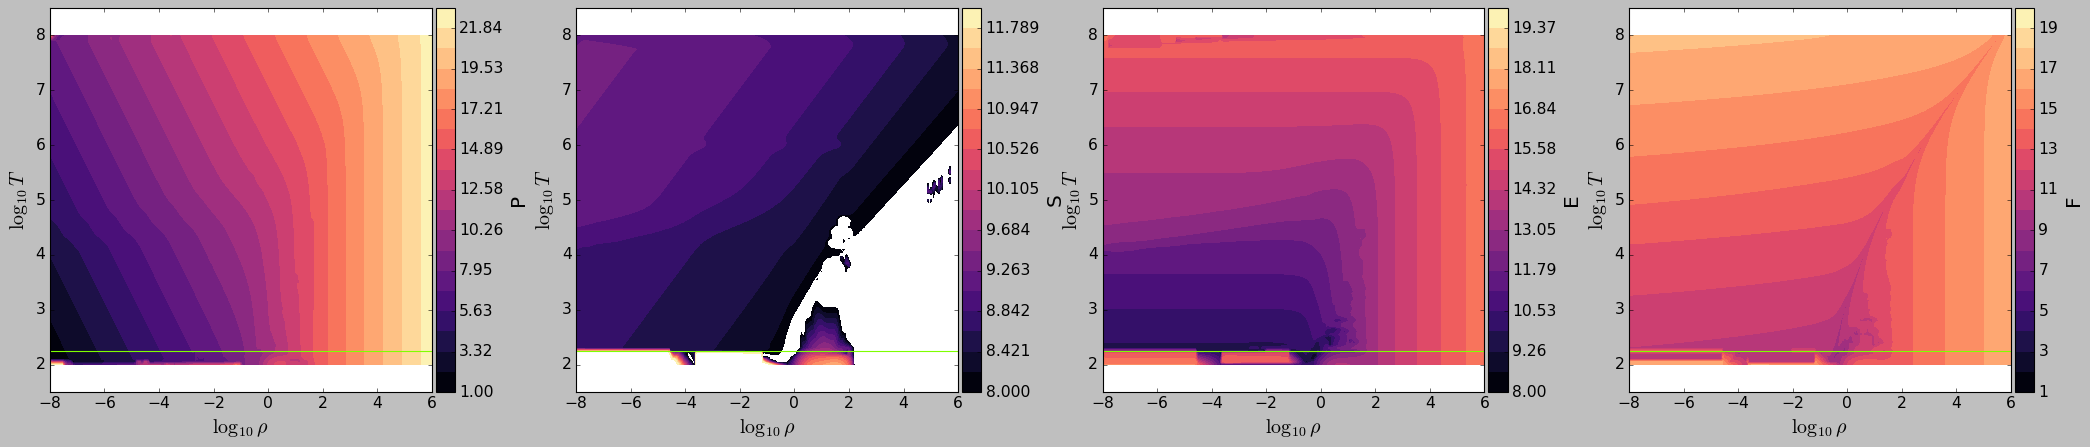

[[-8.   -8.   -8.   ... -8.   -8.   -8.  ]
 [-7.95 -7.95 -7.95 ... -7.95 -7.95 -7.95]
 [-7.9  -7.9  -7.9  ... -7.9  -7.9  -7.9 ]
 ...
 [ 5.9   5.9   5.9  ...  5.9   5.9   5.9 ]
 [ 5.95  5.95  5.95 ...  5.95  5.95  5.95]
 [ 6.    6.    6.   ...  6.    6.    6.  ]]
[[2.   2.05 2.1  ... 7.9  7.95 8.  ]
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]
 ...
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]]
[[22.39699688 15.40662188  1.42587189 ...  7.69643298 15.06542656
  18.751471  ]
 [22.39699688 13.09274679  1.4746216  ...  7.74659342 11.40600999
  15.07874049]
 [22.39699688 12.33770379  1.52336771 ...  7.79675381  9.6013819
  12.3400612 ]
 ...
 [22.24962753 22.24962753 22.24962753 ... 22.28769307 22.2921557
  22.29577773]
 [22.32395772 22.32395772 22.32395772 ... 22.3596883  22.36380185
  22.36714779]
 [22.39699688 22.39699688 22.39699688 ... 22.43062305 22.43442014
  22.43751543]]


/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1871: RuntimeWarning: divide by zero encountered in log10
  cb0.set_label(label=r'$\log_{10}{|\mathrm{dpe}|}$',size=25)
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1885: RuntimeWarning: divide by zero encountered in log10
  cb2.set_label(label=r'$\log_{10}{|\mathrm{dsp}|}$',size=25)


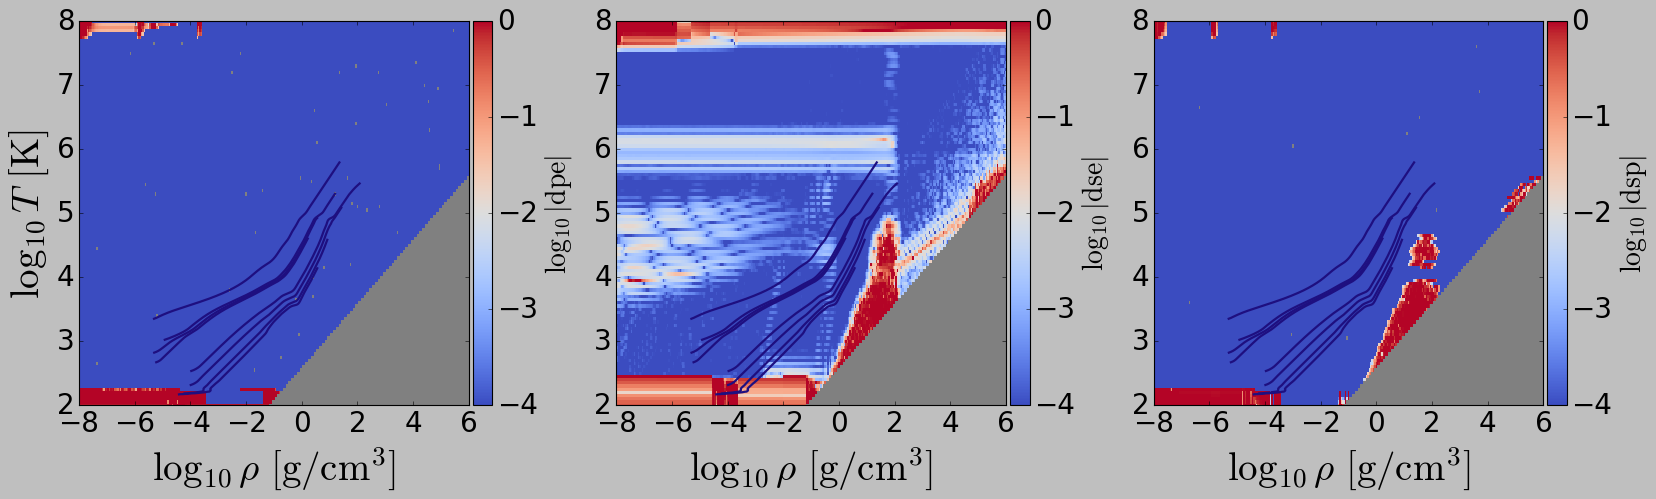

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_30003/3994285155.py:84: RuntimeWarning: divide by zero encountered in divide
  mu_e = 1./( X*((1.-f_H2-f_H)/(2*mu_H)) + Y*((2.-2*f_He-f_Heplus)/(3.*mu_He)) )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_30003/3994285155.py:85: RuntimeWarning: divide by zero encountered in log10
  table.log_free_e = np.log10(1./mu_e)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_30003/3994285155.py:85: RuntimeWarning: invalid value encountered in log10
  table.log_free_e = np.log10(1./mu_e)


[[-6.94309  1.19127  9.32563 ...  7.6872  15.05892 18.7472 ]
 [-6.89309  1.19077  9.27462 ...  7.73724 11.39808 15.07264]
 [-6.84309  1.17484  9.19277 ...  7.78728  9.59268 12.33266]
 ...
 [     nan      nan      nan ... 22.27276 22.27831 22.28284]
 [     nan      nan      nan ... 22.34953 22.35526 22.35995]
 [     nan      nan      nan ... 22.42474 22.43064 22.43547]]


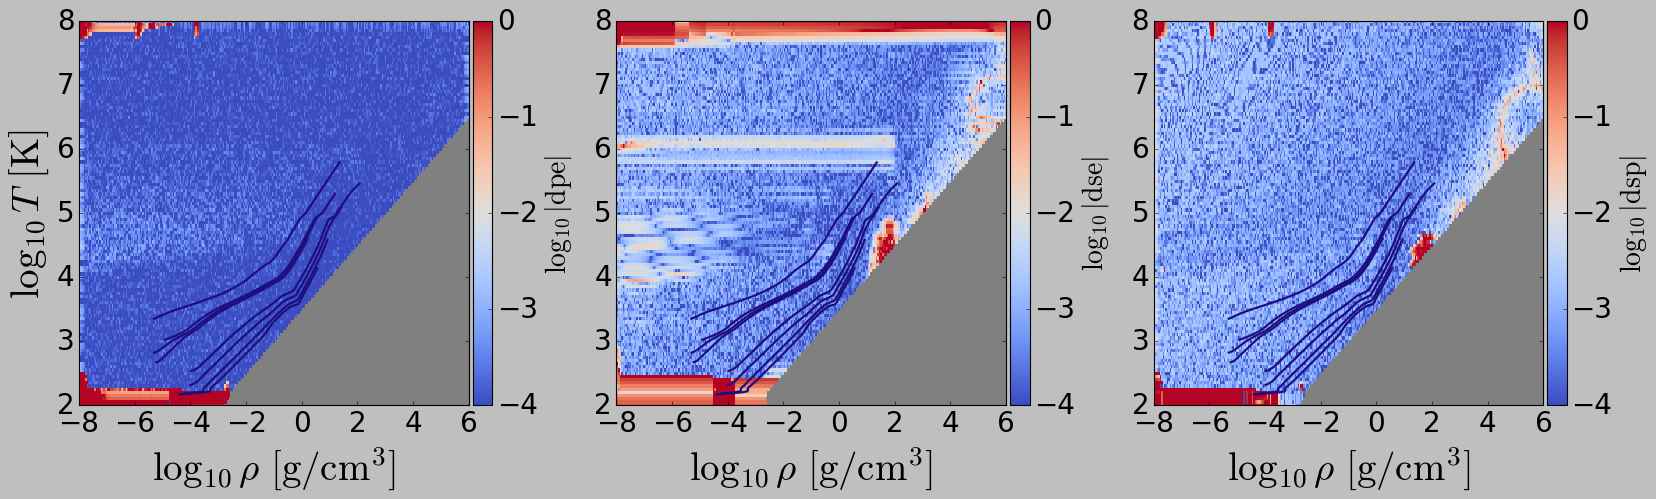

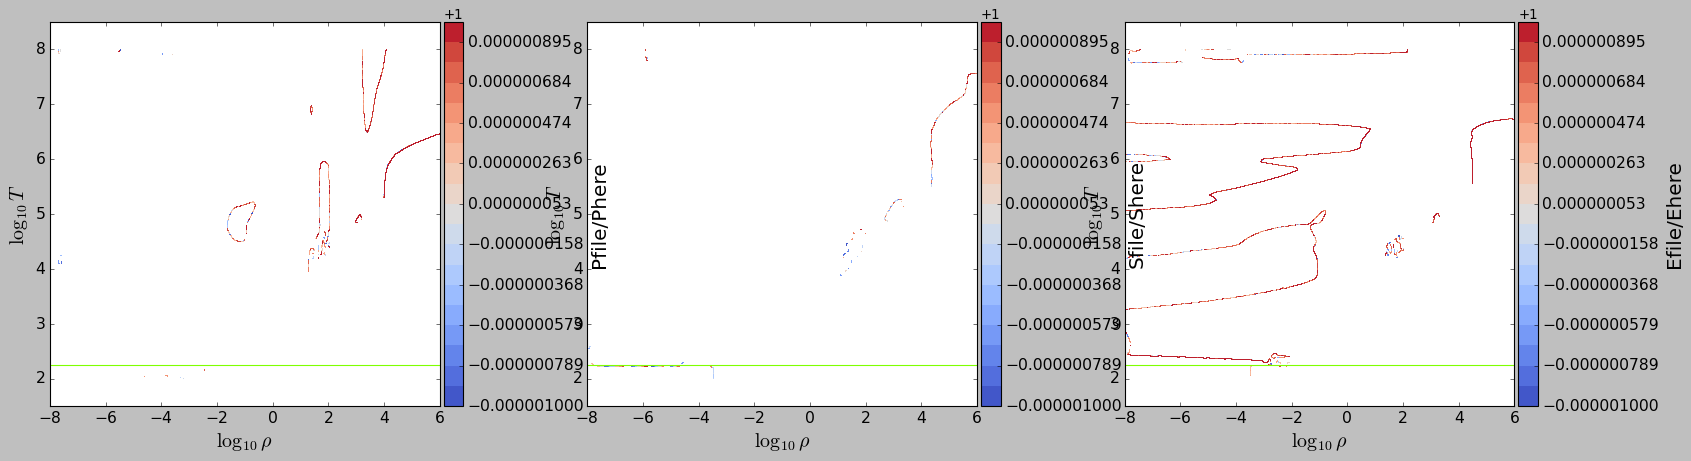

2


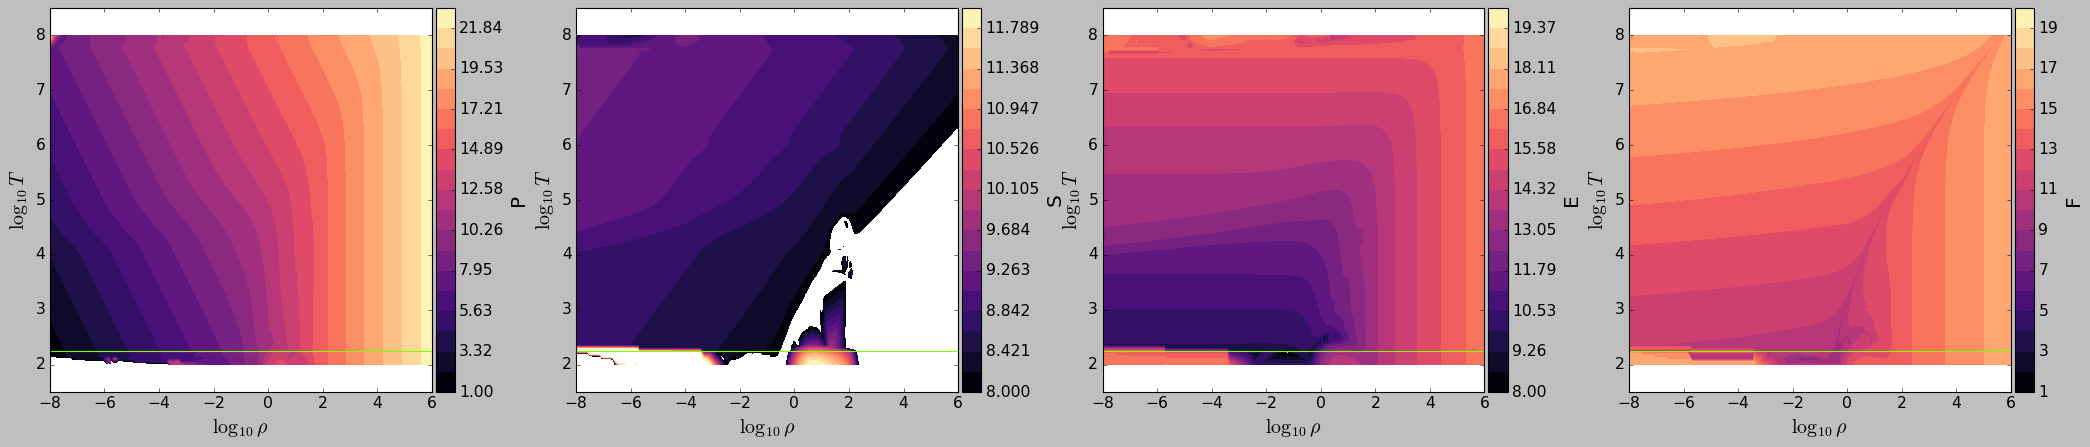

[[-8.   -8.   -8.   ... -8.   -8.   -8.  ]
 [-7.95 -7.95 -7.95 ... -7.95 -7.95 -7.95]
 [-7.9  -7.9  -7.9  ... -7.9  -7.9  -7.9 ]
 ...
 [ 5.9   5.9   5.9  ...  5.9   5.9   5.9 ]
 [ 5.95  5.95  5.95 ...  5.95  5.95  5.95]
 [ 6.    6.    6.   ...  6.    6.    6.  ]]
[[2.   2.05 2.1  ... 7.9  7.95 8.  ]
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]
 ...
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]]
[[-7.66324568 -5.48104509 -2.01827821 ... 18.68675821 20.54189617
  21.47068183]
 [-7.61324568 -5.53361228 -2.01608082 ... 14.99455298 17.76822457
  19.6194532 ]
 [-7.56324568 -5.61814655 -2.02992191 ... 12.24341941 15.00582199
  17.3126376 ]
 ...
 [22.22533736 22.22533736 22.22533736 ... 22.26346632 22.26694493
  22.26978388]
 [22.29334573 22.29334573 22.29334573 ... 22.32902601 22.33225006
  22.33487924]
 [22.36063701 22.36063701 22.36063701 ... 22.39404746 22.39703412
  22.39946749]]


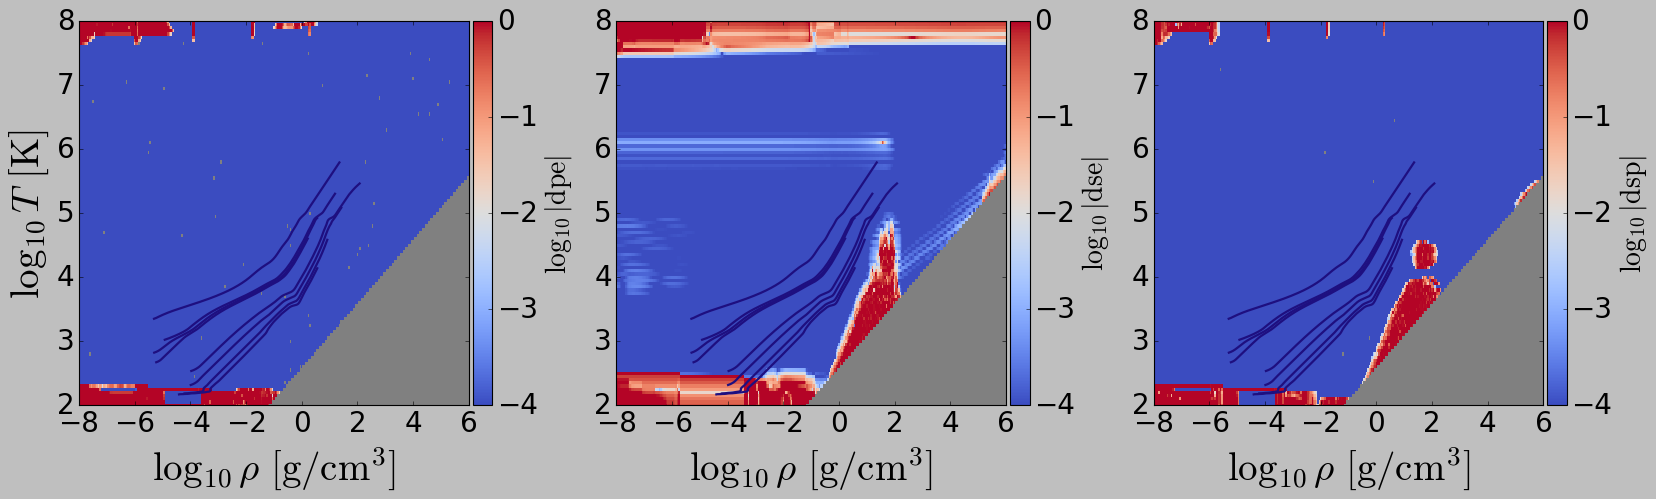

[[-8.08921  0.29245  8.67411 ... 18.67875 20.53433 21.46349]
 [-8.03921  0.1356   8.31041 ... 14.98616 17.76024 19.61187]
 [-7.98921  0.1856   7.14634 ... 12.23472 14.99748 17.30467]
 ...
 [     nan      nan      nan ... 22.24721 22.25078 22.25367]
 [     nan      nan      nan ... 22.3173  22.32078 22.3236 ]
 [     nan      nan      nan ... 22.3865  22.38991 22.39265]]


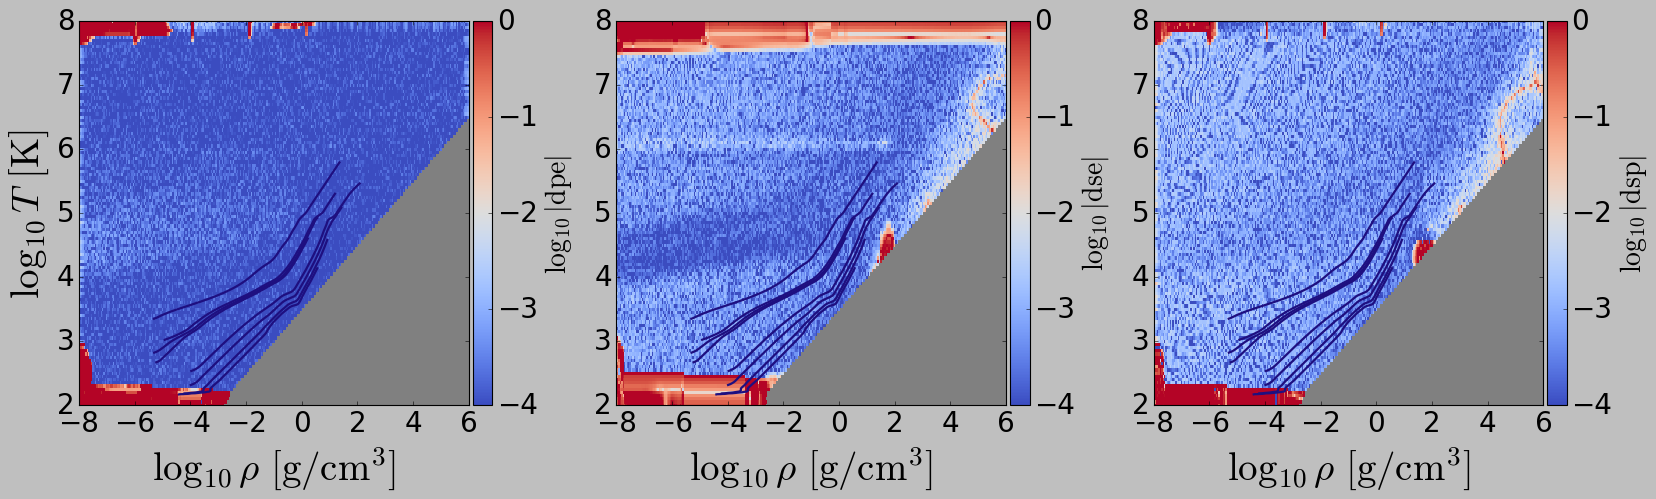

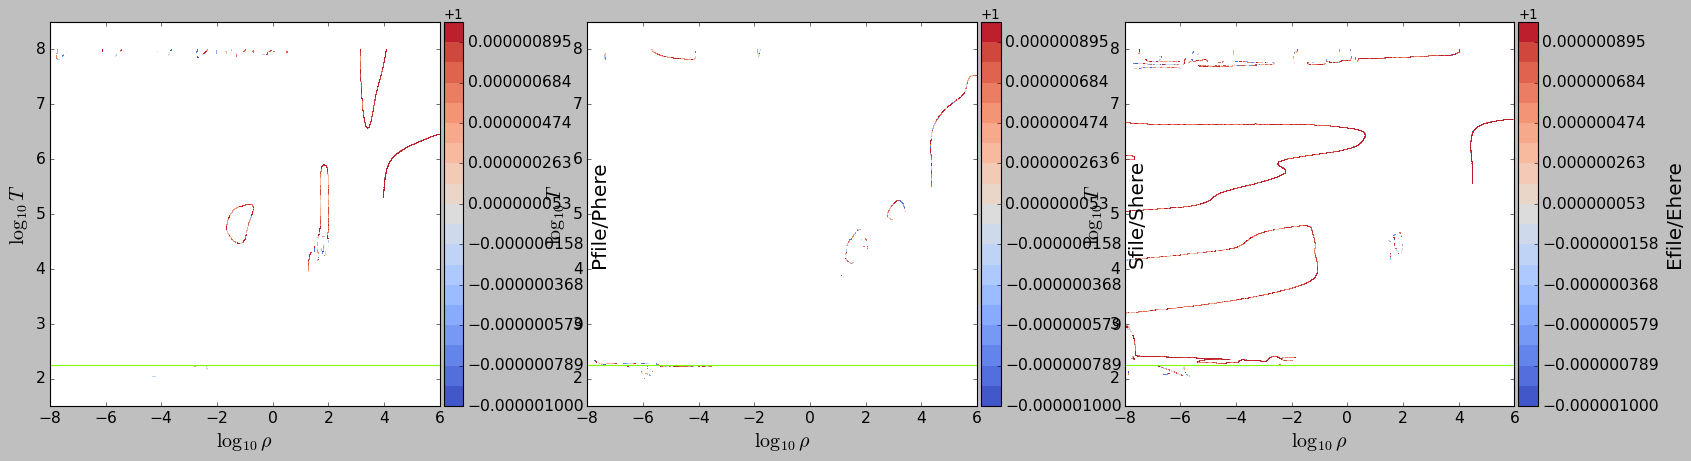

5


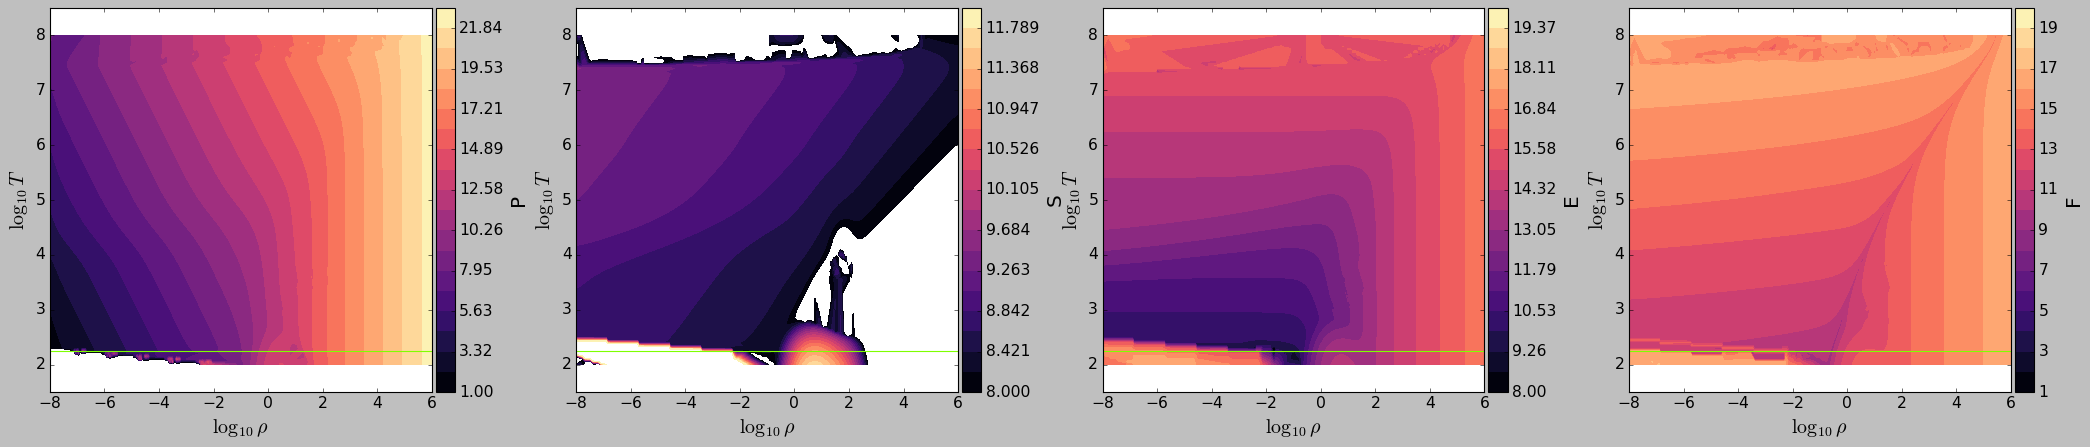

[[-8.   -8.   -8.   ... -8.   -8.   -8.  ]
 [-7.95 -7.95 -7.95 ... -7.95 -7.95 -7.95]
 [-7.9  -7.9  -7.9  ... -7.9  -7.9  -7.9 ]
 ...
 [ 5.9   5.9   5.9  ...  5.9   5.9   5.9 ]
 [ 5.95  5.95  5.95 ...  5.95  5.95  5.95]
 [ 6.    6.    6.   ...  6.    6.    6.  ]]
[[2.   2.05 2.1  ... 7.9  7.95 8.  ]
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]
 ...
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]
 [2.   2.05 2.1  ... 7.9  7.95 8.  ]]
[[-7.40496767 -5.53959818 -4.80376963 ...  7.80480871  8.37903792
   8.50529352]
 [-7.35496767 -5.54529188 -4.82902971 ...  7.91673465  8.01043874
   8.31307769]
 [-7.30496767 -5.55919314 -4.87012356 ...  7.88772777  7.82722892
   7.76673007]
 ...
 [22.02608209 22.02608209 22.02608209 ... 22.06789388 22.07046742
  22.072807  ]
 [22.06318256 22.06318256 22.06318256 ... 22.10249586 22.1049054
  22.10709569]
 [22.09988812 22.09988812 22.09988812 ... 22.13653177 22.13876496
  22.1407946 ]]


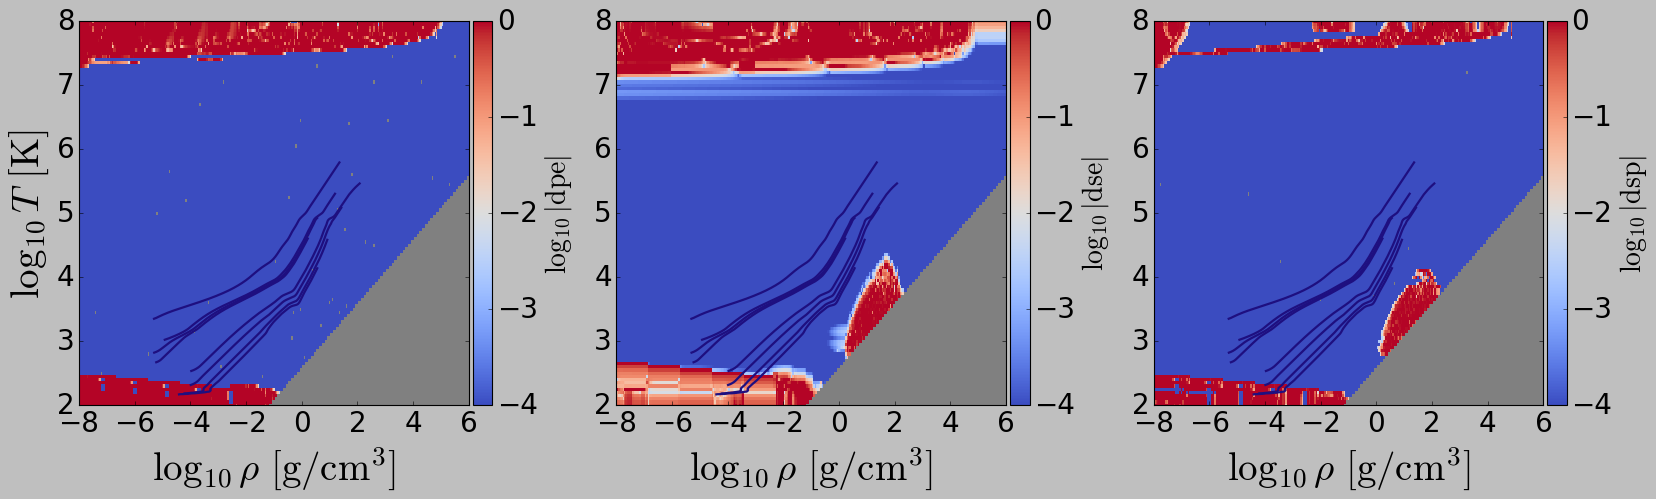

[[-7.17717  3.80714  4.50848 ...  7.78176  8.36083  8.48724]
 [-7.12717  3.77796  4.48217 ...  7.89548  7.98849  8.29355]
 [-7.07717  3.73105  4.43953 ...  7.86726  7.80205  7.73685]
 ...
 [     nan      nan      nan ... 22.04274 22.04507 22.0472 ]
 [     nan      nan      nan ... 22.07958 22.08179 22.08382]
 [     nan      nan      nan ... 22.11601 22.1181  22.12001]]


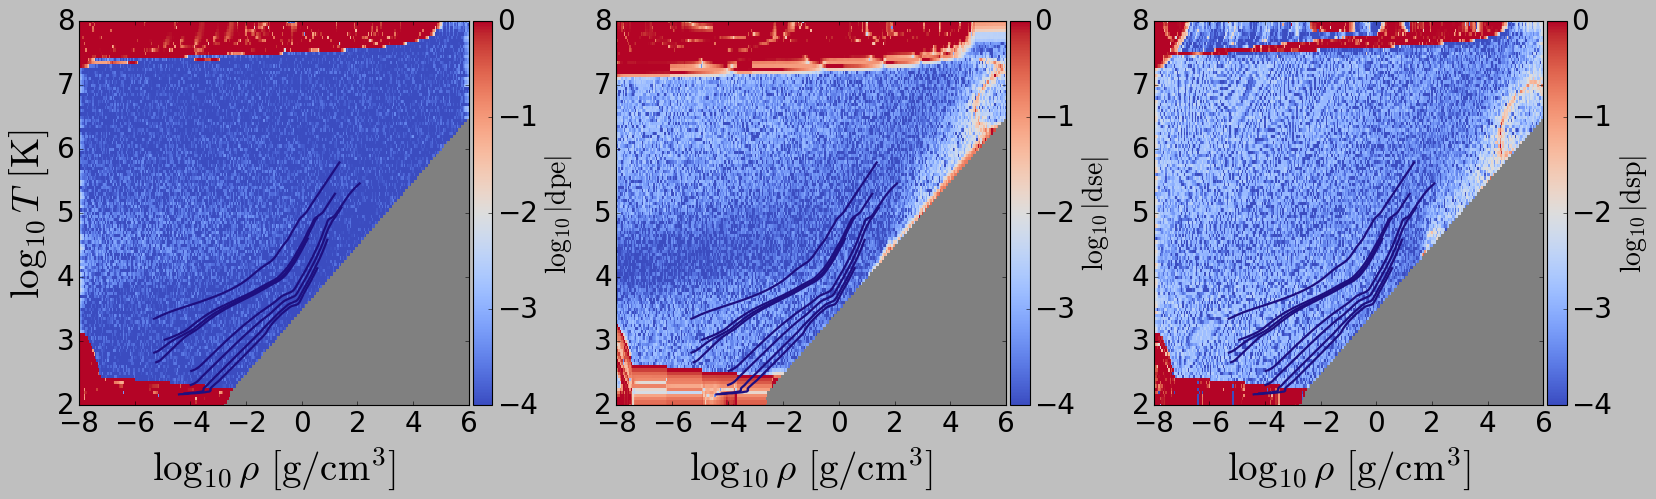

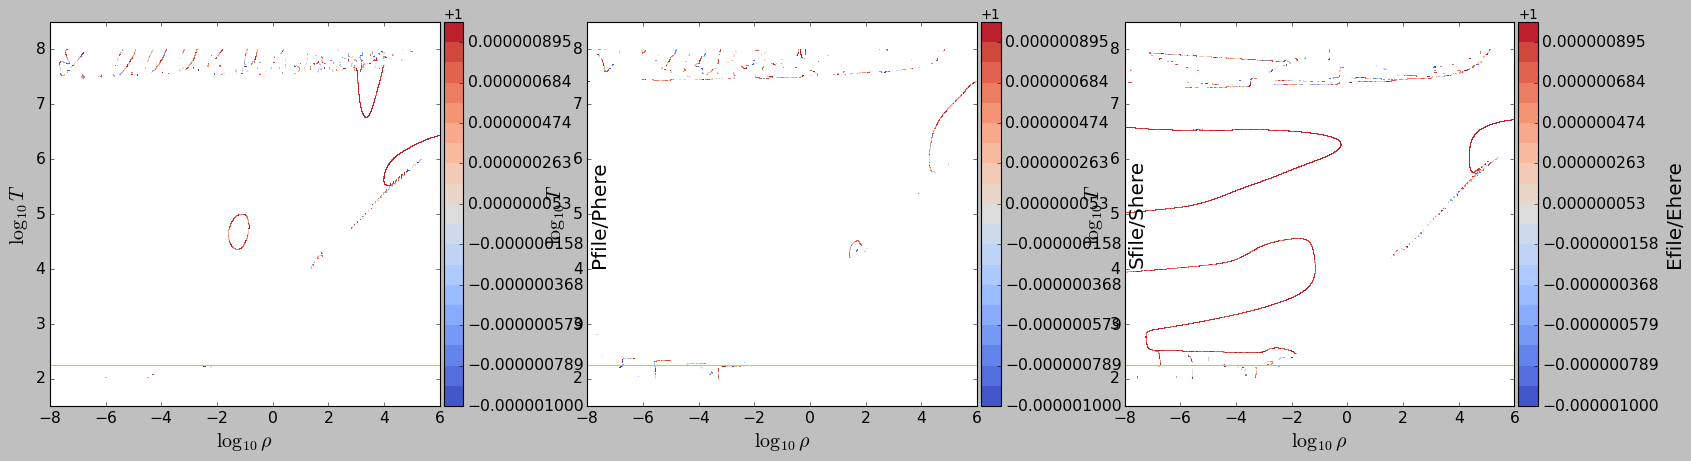

In [31]:
for s_i, s in enumerate(smoothing_arr):
    print(s)
    #infile = open("../cms19_mazevet2022_H_blend.pkl","rb")
    infile = open("../cms19_He_interpolated_over_bad_columns.pkl","rb")
    bln_H_TC = pickle.load(infile)
    infile.close()

    T_lower_limit=None
    T_upper_limit=None
    bln_H_TC.compute_F_table(F_smoothing_kernel=s, F_nan_fill_value=None,T_lower_limit=T_lower_limit,T_upper_limit=T_upper_limit)
    '''
    orig_F = 10**bln_H_TC.log10Egrid - 10**bln_H_TC.log10Tgrid*10**bln_H_TC.log10Sgrid
    final_F = bln_H_TC.Fgrid

    print(len(orig_F[np.isnan(orig_F)]))
    
    meos.contourf_subplots_with_colorbars(nRow=1, nCol=1, 
                                xs=bln_H_TC.log10rhogrid,
                                ys=bln_H_TC.log10Tgrid,
                                zs=[orig_F/final_F],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=(0,2),
                                levels=20,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['Forig/F_final'],
                                cmap='coolwarm', vlines=None, hlines=[2.25], otherlines_x=[unphys_x], otherlines_y=[unphys_y], 
                                species='H', plot_interpolation_lines=False, savename=None)
    
    '''
    '''
    meos.contourf_subplots_with_colorbars(nRow=1, nCol=5, 
                                xs=bln_H_TC.log10rhogrid,
                                ys=bln_H_TC.log10Tgrid,
                                zs=[np.log10(np.abs(10**bln_H_TC.log10Egrid - 10**bln_H_TC.log10Tgrid*10**bln_H_TC.log10Sgrid)),bln_H_TC.F_log10Pgrid,bln_H_TC.F_log10Sgrid,bln_H_TC.F_log10Egrid,np.log10(np.abs(bln_H_TC.Fgrid))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=None,
                                levels=20,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['Forig','P','S','E','F'],
                                cmap='magma', vlines=None, hlines=[2.25], otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename=None)
    '''
    # replace existing PSE grids with F-based versions
    bln_H_TC.log10Pgrid = meos.fill_in_nans(bln_H_TC.F_log10Pgrid,bln_H_TC)
    bln_H_TC.log10Sgrid = meos.fill_in_nans(bln_H_TC.F_log10Sgrid,bln_H_TC)
    bln_H_TC.log10Egrid = meos.fill_in_nans(bln_H_TC.F_log10Egrid,bln_H_TC)
    '''
    if T_lower_limit is not None or T_upper_limit is not None:
        if T_lower_limit is None:
            T_lower_limit = 2.0
        if T_upper_limit is None:
            T_upper_limit = 8.0

        safe_T = np.arange(T_lower_limit,T_upper_limit+0.01,0.05)
        safe_rho = np.arange(-8.,6.01,0.05)
        
        safe_T_mask = (bln_H_TC.log10Tgrid >= T_lower_limit) & (bln_H_TC.log10Tgrid <= T_upper_limit)
        
        P_grid_to_extrapolate = bln_H_TC.log10Pgrid[safe_T_mask].reshape(len(safe_rho),len(safe_T))
        extrap_P = interpolate.RegularGridInterpolator(points=(safe_rho, safe_T), values=P_grid_to_extrapolate, bounds_error=False, fill_value=None, method='linear')
        bln_H_TC.log10Pgrid = extrap_P((bln_H_TC.log10rhogrid,bln_H_TC.log10Tgrid))

        S_grid_to_extrapolate = bln_H_TC.log10Sgrid[safe_T_mask].reshape(len(safe_rho),len(safe_T))
        extrap_S = interpolate.RegularGridInterpolator(points=(safe_rho, safe_T), values=S_grid_to_extrapolate, bounds_error=False, fill_value=None, method='linear')
        bln_H_TC.log10Sgrid = extrap_S((bln_H_TC.log10rhogrid,bln_H_TC.log10Tgrid))

        E_grid_to_extrapolate = bln_H_TC.log10Egrid[safe_T_mask].reshape(len(safe_rho),len(safe_T))
        extrap_E = interpolate.RegularGridInterpolator(points=(safe_rho, safe_T), values=E_grid_to_extrapolate, bounds_error=False, fill_value=None, method='linear')
        bln_H_TC.log10Egrid = extrap_E((bln_H_TC.log10rhogrid,bln_H_TC.log10Tgrid))

    '''
    bln_H_TC.log10Ugrid = bln_H_TC.log10Egrid


    meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=bln_H_TC.log10rhogrid,
                                ys=bln_H_TC.log10Tgrid,
                                zs=[bln_H_TC.log10Pgrid,bln_H_TC.log10Sgrid,bln_H_TC.log10Egrid,np.log10(np.abs(10**bln_H_TC.log10Egrid - ((10**bln_H_TC.log10Tgrid) * (10**bln_H_TC.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(1,23),(8,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=[2.25], otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename=None)
    
    bln_H_TC.compute_partials(species='H')
    print(bln_H_TC.log10rhogrid)
    print(bln_H_TC.log10Tgrid)
    
    print(bln_H_TC.log10Pgrid)
    
    dpe, dse, dsp, a, b, c = meos.consistency_metrics(bln_H_TC, P=10**bln_H_TC.log10Pgrid,S=10**bln_H_TC.log10Sgrid,E=10**bln_H_TC.log10Egrid,species='H',order=8,maskUnphysicalRegion=True,paperplot=True,plot_tracks=True,profiles=profiles,savename=None)

    MESA_cols_6to16(bln_H_TC,X=1.,Y=0.,calc_eta=False)
    #end = time.time()
    #print((end-start)/60.)
    
    bln_H_TC.log10Qgrid = bln_H_TC.log10rhogrid - 2.*bln_H_TC.log10Tgrid + 12

    bln_H_TC_QT = change_table_coordinates(bln_H_TC,extrapolation_row_idxs=None)
    
    
    TC_tabulated = QT_to_rhot(bln_H_TC_QT,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2)
    
    
    '''
    meos.contourf_subplots_with_colorbars(nRow=1, nCol=3, 
                                xs=TC_tabulated.log10rhogrid,
                                ys=TC_tabulated.log10Tgrid,
                                zs=[TC_tabulated.log10Pgrid,TC_tabulated.log10Sgrid,TC_tabulated.log10Egrid],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=None,
                                levels=20,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E'],
                                cmap='magma', vlines=None, hlines=[2.25], otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename=None)

    '''
    #TC_tabulated_QT = meos.read_MESAtable("../meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-TC_s={0}_00z100x.data".format(s))
    TC_tabulated_QT = meos.read_MESAtable("../meos_MESAformat_CMS19+HG23+rock+water/mesa-planetblend-TC_s={0}_10z00x.data".format(s))
    
    TC_tabulated_rhoT, TC_tabulated = meos.reshapeQTgrid(TC_tabulated_QT,lower_logRho_bound=-8,upper_logRho_bound=6,rounding=2)
    TC_tabulated.X = 1.
    TC_tabulated.Y = 0.
    TC_tabulated.Z = 0.
    TC_tabulated.compute_atomic_number()

    print(TC_tabulated.log10Pgrid)
    
    TC_tabulated_dpe, TC_tabulated_dse, TC_tabulated_dsp, TC_tabulated_a, TC_tabulated_b, TC_tabulated_c = meos.consistency_metrics(TC_tabulated, P=10**TC_tabulated.log10Pgrid,S=10**TC_tabulated.log10Sgrid,E=10**TC_tabulated.log10Egrid,species='H',order=8,maskUnphysicalRegion=True,paperplot=True,plot_tracks=True,profiles=profiles,savename=None)

    meos.contourf_subplots_with_colorbars(nRow=1, nCol=3, 
                                xs=TC_tabulated.log10rhogrid,
                                ys=TC_tabulated.log10Tgrid,
                                zs=[TC_tabulated.log10Pgrid/bln_H_TC.log10Pgrid,TC_tabulated.log10Sgrid/bln_H_TC.log10Sgrid,TC_tabulated.log10Egrid/bln_H_TC.log10Egrid],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=(0.999999,1.000001),
                                levels=20,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['Pfile/Phere','Sfile/Shere','Efile/Ehere'],
                                cmap='coolwarm', vlines=None, hlines=[2.25], otherlines_x=None, otherlines_y=None, 
                                species='H', plot_interpolation_lines=False, savename=None)
